**Bölüm 1 – Büyük Ölçekli Sentetik Veri Seti Oluşturma**

Bu bölümde, iş arayan ajanları temsil eden büyük ölçekli bir sentetik veri seti oluşturulmaktadır.
Her ajan; demografik, eğitim, teknik beceri, davranışsal ve sosyoekonomik faktörleri kapsayan 300 adet yapılandırılmış öznitelik ile tanımlanmaktadır.
Seçili özniteliklerden türetilen gizli bir iş bulma potansiyeli (job potential) skoru hesaplanmakta ve gerçekçi istihdam çıktıları elde edilmektedir.

 Oluşturulan sentetik veri seti, ileri analizlerde ve simülasyon bileşeninde kullanılmak üzere Excel formatında kaydedilmektedir.

In [1]:
import numpy as np
import pandas as pd

# ==============================
# Parameters
# ==============================
N_AGENTS = 500
SEED = 42
np.random.seed(SEED)

# ==============================
# 1️⃣ Define 300 named attributes
# ==============================
demographics = [f'dem_{i+1}' for i in range(10)]
education = [f'edu_{i+1}' for i in range(30)]
technical_skills = [f'tech_{i+1}' for i in range(50)]
soft_skills = [f'soft_{i+1}' for i in range(30)]
work_experience = [f'work_{i+1}' for i in range(20)]
job_search = [f'jobsearch_{i+1}' for i in range(20)]
digital_footprint = [f'digital_{i+1}' for i in range(30)]
personality = [f'pers_{i+1}' for i in range(30)]
socioeconomic = [f'socio_{i+1}' for i in range(20)]
health = [f'health_{i+1}' for i in range(10)]
extra_attributes = [f'extra_{i+1}' for i in range(50)]

attribute_names = (
    demographics + education + technical_skills + soft_skills +
    work_experience + job_search + digital_footprint +
    personality + socioeconomic + health + extra_attributes
)

print(f"Total attributes: {len(attribute_names)}")  # MUST be 300

# ==============================
# 2️⃣ Generate BASE synthetic data
# ==============================
features = np.random.rand(N_AGENTS, len(attribute_names))
agents_df = pd.DataFrame(features, columns=attribute_names)
agents_df.insert(0, 'agent_id', np.arange(N_AGENTS))

# ==============================
# 3️⃣ Create STRUCTURED latent scores
# ==============================
agents_df['tech_score'] = agents_df[technical_skills].mean(axis=1)
agents_df['soft_score'] = agents_df[soft_skills].mean(axis=1)
agents_df['edu_score'] = agents_df[education].mean(axis=1)
agents_df['work_score'] = agents_df[work_experience].mean(axis=1)
agents_df['job_search_score'] = agents_df[job_search].mean(axis=1)

# ==============================
# 4️⃣ Job-finding potential (CORE TARGET)
# ==============================
agents_df['job_potential'] = (
    0.35 * agents_df['tech_score'] +
    0.25 * agents_df['soft_score'] +
    0.20 * agents_df['edu_score'] +
    0.15 * agents_df['work_score'] +
    0.05 * agents_df['job_search_score']
)

# Normalize job potential to [0,1]
agents_df['job_potential'] = (
    agents_df['job_potential'] - agents_df['job_potential'].min()
) / (
    agents_df['job_potential'].max() - agents_df['job_potential'].min()
)

# ==============================
# 5️⃣ Employment outcome (NOT random)
# ==============================
agents_df['has_job'] = agents_df['job_potential'] > np.random.uniform(0.45, 0.75, N_AGENTS)

agents_df['round_hired'] = np.where(
    agents_df['has_job'],
    np.random.randint(1, 6, size=N_AGENTS),
    -1
)

agents_df['applications_made'] = (
    (1 - agents_df['job_potential']) * np.random.randint(5, 30, size=N_AGENTS)
).astype(int)

# ==============================
# 6️⃣ Drop helper columns (optional but recommended)
# ==============================
agents_df.drop(
    columns=['tech_score', 'soft_score', 'edu_score', 'work_score', 'job_search_score'],
    inplace=True
)

# ==============================
# 7️⃣ Save dataset
# ==============================
agents_df.to_excel('agents_300_named_FINAL.xlsx', index=False)
print("✅ Saved structured dataset: agents_300_named_FINAL.xlsx")

# Preview
agents_df.head()


Total attributes: 300
✅ Saved structured dataset: agents_300_named_FINAL.xlsx


,agent_id,dem_1,dem_2,dem_3,dem_4,dem_5,dem_6,dem_7,dem_8,dem_9,...,extra_45,extra_46,extra_47,extra_48,extra_49,extra_50,job_potential,has_job,round_hired,applications_made
0,0,0.374540,0.950714,0.731994,0.598658,0.156019,0.155995,0.058084,0.866176,0.601115,...,0.127061,0.522243,0.769994,0.215821,0.622890,0.085347,0.358882,False,-1,10
1,1,0.051682,0.531355,0.540635,0.637430,0.726091,0.975852,0.516300,0.322956,0.795186,...,0.896788,0.473962,0.667558,0.172320,0.192289,0.040869,0.445824,False,-1,12
2,2,0.168935,0.278590,0.177010,0.088703,0.120636,0.460779,0.206334,0.364270,0.503417,...,0.668085,0.204984,0.293148,0.896336,0.013002,0.085509,0.323367,False,-1,19
3,3,0.207886,0.026532,0.181435,0.583042,0.421425,0.892672,0.817444,0.341817,0.259423,...,0.045742,0.871537,0.973489,0.968878,0.749652,0.130086,0.550673,False,-1,4
4,4,0.758263,0.024587,0.022124,0.323610,0.488643,0.770407,0.683295,0.445903,0.273627,...,0.603449,0.668213,0.619490,0.463494,0.379786,0.863334,0.401528,False,-1,9


**Bölüm 2 – Ajan Tabanlı İşgücü Piyasası Simülasyonu**

Bu bölümde, ajan tabanlı bir işgücü piyasası simülasyonu uygulanmaktadır.
İş arayan ajanlar, piyasa zorluk seviyesi ve bireysel iş potansiyellerine bağlı olarak simüle edilmiş bir işgücü piyasası ile etkileşime girmektedir.
Simülasyon birden fazla tur boyunca çalıştırılmakta ve istihdam dinamikleri kayıt altına alınmaktadır.

Aşağıda yer alan grafikler, simülasyon süresince istihdamın zamansal gelişimini, işe alım davranışlarını ve iş potansiyeli ile işe alınma zamanı arasındaki ilişkiyi görselleştirmektedir.

,agent_id,employed,round_hired,job_potential
0,0,False,NaN,0.278844
1,1,False,NaN,0.285300
2,2,True,9.0,0.445026
3,3,True,1.0,0.832241
4,4,True,7.0,0.566611


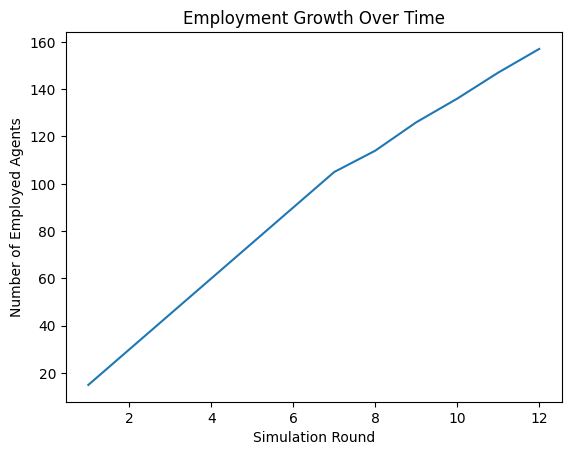

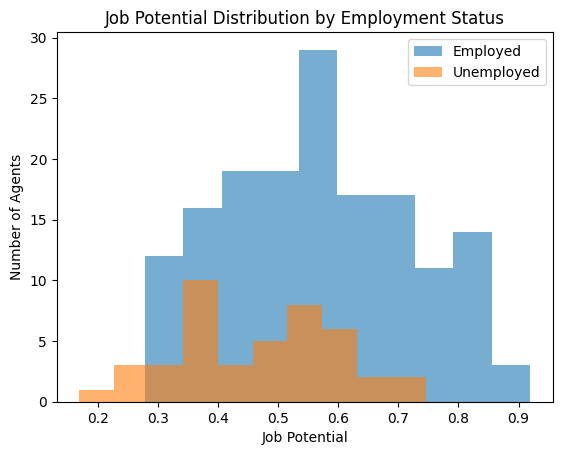

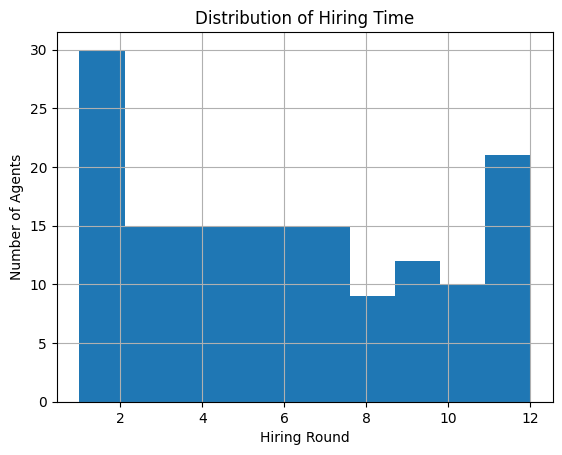

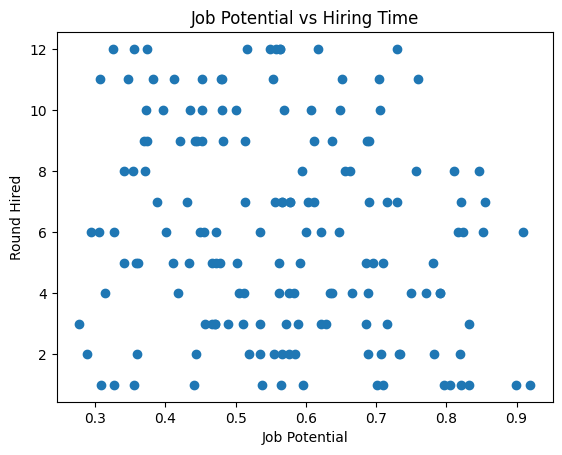

In [2]:
import random
import pandas as pd
import numpy as np

random.seed(42)
np.random.seed(42)

class JobSeekerAgent:
    def __init__(self, agent_id, attributes):
        """
        Initialize a job seeker agent.

        Parameters:
        - agent_id: unique identifier
        - attributes: dictionary containing agent features
        """
        self.agent_id = agent_id

        # Observable attributes
        self.education = attributes.get("education")
        self.skills = attributes.get("skills")
        self.experience = attributes.get("experience")
        self.job_search_intensity = attributes.get("job_search_intensity")
        self.digital_presence = attributes.get("digital_presence")

        # Hidden attribute (latent)
        self.job_potential = attributes.get("job_potential")

        # State
        self.employed = False
        self.round_hired = None

        # Data validation
        assert 0 <= self.job_search_intensity <= 1
        assert 0 <= self.job_potential <= 1


    def apply_for_jobs(self):
        """
        Decide whether the agent applies for a job in this round.
        """
        if self.employed:
            return False

        # Probability of applying depends on job search intensity
        probability = min(1.0, self.job_search_intensity)
        return random.random() < probability

# //////////////////////////////////////////


class LaborMarket:
    def __init__(self, jobs_per_round, market_difficulty):
        """
        Initialize the labor market environment.

        Parameters:
        - jobs_per_round: number of available jobs each round
        - market_difficulty: hiring strictness (0–1)
        """
        self.jobs_per_round = jobs_per_round
        self.market_difficulty = market_difficulty

    def evaluate_applicants(self, applicants):
        """
        Evaluate applicants and select hires probabilistically.
        """
        hired_agents = []

        # Shuffle applicants to avoid ordering bias
        random.shuffle(applicants)

        for agent in applicants:
            if len(hired_agents) >= self.jobs_per_round:
                break

            # Hiring probability depends on latent job potential
            # hiring_probability = agent.job_potential * (1 - self.market_difficulty)
            # Add small market uncertainty
            effective_difficulty = self.market_difficulty + random.uniform(-0.05, 0.05)
            effective_difficulty = min(max(effective_difficulty, 0), 1)

            hiring_probability = agent.job_potential * (1 - effective_difficulty)


            if random.random() < hiring_probability:
                hired_agents.append(agent)

        return hired_agents

# ////////////////////////////////////////////

def generate_agents(num_agents):
    agents = []

    for i in range(num_agents):
        # Generate observable attributes
        attributes = {
            "education": random.choice([0, 1, 2, 3]),  # education levels
            "skills": random.uniform(0.2, 1.0),
            "experience": random.uniform(0, 5),
            "job_search_intensity": random.uniform(0.3, 1.0),
            "digital_presence": random.uniform(0.2, 1.0)
        }

        # STEP 2: Build latent job_potential from observable features
        job_potential = (
            0.3 * attributes["skills"] +
            0.3 * (attributes["education"] / 3) +
            0.2 * (attributes["experience"] / 5) +
            0.2 * attributes["digital_presence"]
        )

        # Ensure value is within [0, 1]
        job_potential = min(1.0, job_potential)

        # Add latent variable to attributes
        attributes["job_potential"] = job_potential

        agent = JobSeekerAgent(i, attributes)
        agents.append(agent)

    return agents



# //////////////////////////////////////////////////

def run_simulation(agents, labor_market, max_rounds=12):
    """
    Run the agent-based simulation.
    """
    results = []

    for current_round in range(1, max_rounds + 1):
        applicants = []

        # Agents decide whether to apply
        for agent in agents:
            if agent.apply_for_jobs():
                applicants.append(agent)

        # Labor market evaluates applicants
        hired_agents = labor_market.evaluate_applicants(applicants)

        # Update states
        for agent in hired_agents:
            agent.employed = True
            agent.round_hired = current_round

        # Collect statistics
        employed_count = sum(agent.employed for agent in agents)

        employment_rate = employed_count / len(agents)

        results.append({
            "round": current_round,
            "employed_agents": employed_count,
            "unemployed_agents": len(agents) - employed_count ,
            "employment_rate": employment_rate
        })

        # Stop early if all agents are employed
        if employed_count == len(agents):
            break

    return pd.DataFrame(results), agents

# /////////////////////////////////////////////
# Create agents
agents = generate_agents(num_agents=200)

# Create labor market
labor_market = LaborMarket(
    jobs_per_round=15,
    market_difficulty=0.4
)

# Run simulation
simulation_results, final_agents = run_simulation(
    agents,
    labor_market,
    max_rounds=12
)

simulation_results

# /////////////////////////////////////////////////
# Final employment summary
employment_data = pd.DataFrame([
    {
        "agent_id": agent.agent_id,
        "employed": agent.employed,
        "round_hired": agent.round_hired,
        "job_potential": agent.job_potential
    }
    for agent in final_agents
])


from IPython.display import display

display(employment_data.head())



# /////////////////////////////////////
# Visulaization

import matplotlib.pyplot as plt

plt.figure()
plt.plot(simulation_results["round"], simulation_results["employed_agents"])
plt.xlabel("Simulation Round")
plt.ylabel("Number of Employed Agents")
plt.title("Employment Growth Over Time")
plt.show()



plt.figure()
plt.hist(
    employment_data[employment_data["employed"] == True]["job_potential"],
    alpha=0.6,
    label="Employed"
)
plt.hist(
    employment_data[employment_data["employed"] == False]["job_potential"],
    alpha=0.6,
    label="Unemployed"
)
plt.xlabel("Job Potential")
plt.ylabel("Number of Agents")
plt.title("Job Potential Distribution by Employment Status")
plt.legend()
plt.show()


plt.figure()
employment_data["round_hired"].dropna().hist()
plt.xlabel("Hiring Round")
plt.ylabel("Number of Agents")
plt.title("Distribution of Hiring Time")
plt.show()


plt.figure()
plt.scatter(
    employment_data["job_potential"],
    employment_data["round_hired"]
)
plt.xlabel("Job Potential")
plt.ylabel("Round Hired")
plt.title("Job Potential vs Hiring Time")
plt.show()

